In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
data = df['Temp'].values.reshape(-1, 1)

In [5]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [7]:
def create_dataset(series, time_step=30):
    X, y = [], []
    for i in range(time_step, len(series)):
        X.append(series[i-time_step:i])
        y.append(series[i])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(data_scaled, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [9]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [11]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(time_step, 1)))   # 1ère couche LSTM
model.add(LSTM(64, return_sequences=True))                               # 2ème couche LSTM
model.add(LSTM(64))                                                      # 3ème couche LSTM
model.add(Dense(1))                                                      # Sortie

model.compile(loss='mse', optimizer='adam')
model.summary()

C:\Users\yasmi\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,009 (324.25 KB)

 Trainable params: 83,009 (324.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 0.0380 - val_loss: 0.0105
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0131 - val_loss: 0.0105
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0118 - val_loss: 0.0114
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0119 - val_loss: 0.0100
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0122 - val_loss: 0.0120
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0121 - val_loss: 0.0097
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0117 - val_loss: 0.0095
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0119 - val_loss: 0.0101
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0117 - val_loss: 0.0085
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.0101 - val_loss: 0.0082
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0100 - val_loss: 0.0077
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.

In [15]:
y_pred = model.predict(X_test)
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step


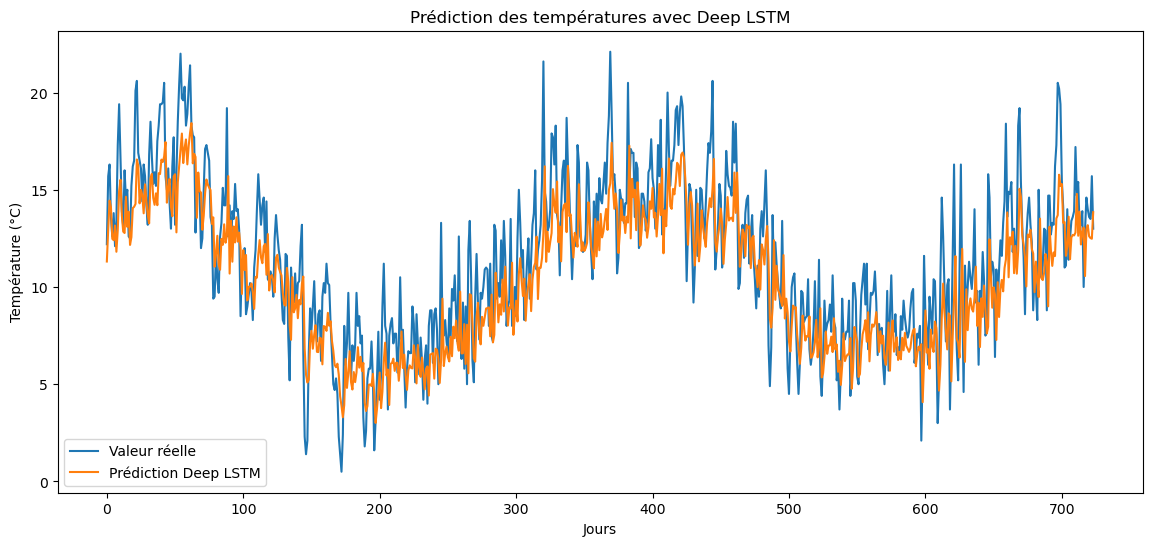

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Valeur réelle')
plt.plot(y_pred_rescaled, label='Prédiction Deep LSTM')
plt.title('Prédiction des températures avec Deep LSTM')
plt.xlabel('Jours')
plt.ylabel('Température (°C)')
plt.legend()
plt.show()